In [ ]:
 #노트북이 코랩에서 실행 중인지 체크합니다.

import sys
if 'google.colab' in sys.modules:
  !echo 'debconf debconf/frontend select Noniteractive' | \
  debconf-set-selections

  # 나눔 폰트를 설치합니다.
  !sudo apt-get -qq -y install fonts-nanum
  import matplotlib.font_manager as fm
  font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
  for fpath in font_files:
    fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Noniteractive
debconf: (Can't locate Debconf/FrontEnd/Noniteractive.pm in @INC (you may need to install the Debconf::FrontEnd::Noniteractive module) (@INC contains: /etc/perl /usr/local/lib/x86_64-linux-gnu/perl/5.34.0 /usr/local/share/perl/5.34.0 /usr/lib/x86_64-linux-gnu/perl5/5.34 /usr/share/perl5 /usr/lib/x86_64-linux-gnu/perl-base /usr/lib/x86_64-linux-gnu/perl/5.34 /usr/share/perl/5.34 /usr/local/lib/site_perl) at (eval 17) line 2, <> line 1.)
debconf: falling back to frontend: Noninteractive
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['figure.dpi']=100

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


   Year   Total    Male  Female
0  2015  519584  262814  256770
1  2016  516775  261105  255670
2  2017  513832  259491  254341
3  2018  510013  257789  252224
4  2019  507025  256140  250885
5  2020  502916  254222  248694
6  2021  503852  255292  248560
7  2022  496650  251630  245020
8  2023  493033  250242  242791
9  2024  491581  249710  241871


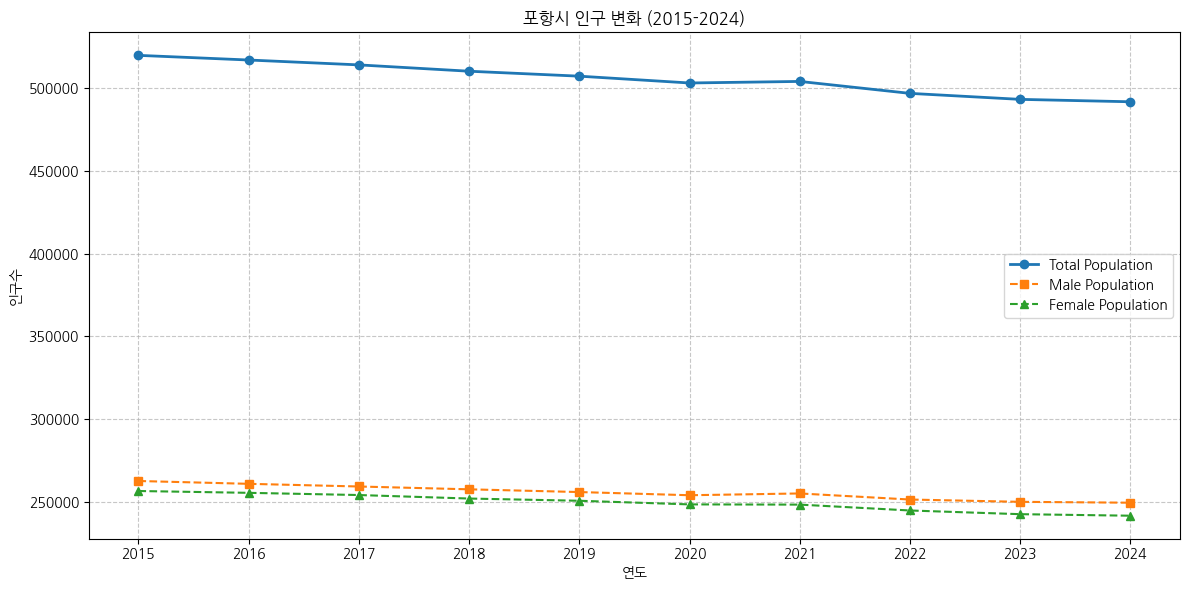

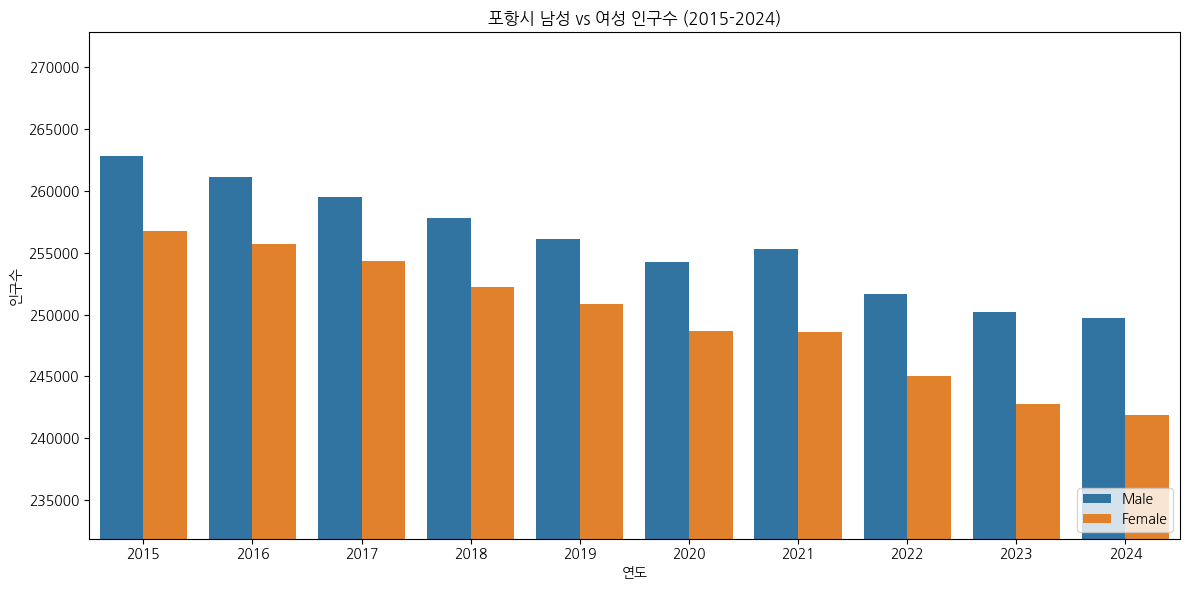

In [ ]:
import pandas as pd

# Load the data file
file_path = '/content/행정구역_시군구_별__성별_인구수_20251218184515.xlsx'
df = pd.read_excel(file_path)

import matplotlib.pyplot as plt
import seaborn as sns

# Set font for Korean support (using a common font available in many environments)
plt.rcParams['font.family'] = 'NanumGothic' # Or another font if available. Let's use a standard way.
# Since I cannot guarantee NanumGothic, I'll use a basic setting and provide English labels if needed,
# but usually, these environments have some support. I will try to use a more robust way if possible.

# Load and prepare data
df = pd.read_excel('/content/행정구역_시군구_별__성별_인구수_20251218184515.xlsx')

# Extract actual data for Pohang (Row 1)
pohang_data = df.iloc[1, 1:].values
pohang_data = [int(x) for x in pohang_data]

# Labels
years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
total_pop = pohang_data[0::3]
male_pop = pohang_data[1::3]
female_pop = pohang_data[2::3]

# Create a clean DataFrame for plotting
plot_df = pd.DataFrame({
    'Year': years,
    'Total': total_pop,
    'Male': male_pop,
    'Female': female_pop
})

# Visualization 1: Line Chart for Trends
plt.figure(figsize=(12, 6))
plt.plot(plot_df['Year'], plot_df['Total'], marker='o', label='Total Population', linewidth=2)
plt.plot(plot_df['Year'], plot_df['Male'], marker='s', label='Male Population', linestyle='--')
plt.plot(plot_df['Year'], plot_df['Female'], marker='^', label='Female Population', linestyle='--')

plt.title('포항시 인구 변화 (2015-2024)')
plt.xlabel('연도')
plt.ylabel('인구수')
plt.xticks(years)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('pohang_population_trend.png')

# Visualization 2: Bar Chart for Sex Ratio Comparison
plot_df_melted = plot_df.melt(id_vars='Year', value_vars=['Male', 'Female'], var_name='Gender', value_name='Population')

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df_melted, x='Year', y='Population', hue='Gender')
plt.title('포항시 남성 vs 여성 인구수 (2015-2024)')
plt.xlabel('연도')
plt.ylabel('인구수')
plt.ylim(min(female_pop) - 10000, max(male_pop) + 10000)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('pohang_gender_comparison.png')

print(plot_df)

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. 데이터 로드 및 모델 학습 (초기 1회 실행)
file_name = '/content/행정구역_시군구_별__성별_인구수_20251218184515.xlsx'
df = pd.read_excel(file_name)

# 데이터 전처리: 포항시 총인구수 추출
pohang_raw = df.iloc[1, 1:].values
pohang_total_pop = [int(pohang_raw[i]) for i in range(0, len(pohang_raw), 3)]

# 학습 데이터 설정
years = np.array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]).reshape(-1, 1)
population = np.array(pohang_total_pop)

# 선형 회귀 모델 학습
model = LinearRegression()
model.fit(years, population)

print("="*50)
print("포항시 인구수 예측 머신러닝 프로그램에 오신 것을 환영합니다.")
print("2015~2024년 데이터를 바탕으로 미래 인구를 예측합니다.")
print("종료하려면 'q'를 입력하세요.")
print("="*50)

# 2. 반복 입력 루프 시작
while True:
    user_input = input("\n예측하고 싶은 연도를 입력하세요 (예: 2025) [종료: q]: ").strip()

    # 종료 조건 확인
    if user_input.lower() == 'q':
        print("\n프로그램을 종료합니다. 이용해 주셔서 감사합니다!")
        break

    try:
        # 입력값을 정수로 변환
        target_year = int(user_input)

        if target_year <= 2024:
            print(">> 참고: 2024년 이전 데이터는 이미 결과가 있습니다. 2025년 이후를 입력해 보세요.")

        # 모델을 통한 예측값 계산
        prediction = model.predict(np.array([[target_year]]))
        result = int(prediction[0])

        # 결과 출력
        print(f"[{target_year}년 예측 결과]")
        print(f"▶ 예상 인구수: 약 {result:,} 명")

        # 간단한 분석 멘트
        annual_change = int(model.coef_[0])
        print(f"※ 모델 분석: 포항시 인구는 매년 약 {abs(annual_change):, Rose}명씩 감소하는 추세입니다.")

    except ValueError:
        print(">> 잘못된 입력입니다. '연도(숫자)'를 입력하거나 종료하려면 'q'를 입력하세요.")

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


포항시 인구수 예측 머신러닝 프로그램에 오신 것을 환영합니다.
2015~2024년 데이터를 바탕으로 미래 인구를 예측합니다.
종료하려면 'q'를 입력하세요.

예측하고 싶은 연도를 입력하세요 (예: 2025) [종료: q]: 2026
[2026년 예측 결과]
▶ 예상 인구수: 약 484,776 명
>> 잘못된 입력입니다. '연도(숫자)'를 입력하거나 종료하려면 'q'를 입력하세요.

예측하고 싶은 연도를 입력하세요 (예: 2025) [종료: q]: q

프로그램을 종료합니다. 이용해 주셔서 감사합니다!
